# WSTĘP

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from xgboost import XGBClassifier, plot_importance

from visualization import visualize_categorical_feature_distributions, visualize_numeric_feature_distributions, visualize_binary_feature_distributions, visualize_target_distribution

### ŁADOWANIE DANYCH


In [2]:
data = pd.read_csv('banking_transactions.csv')
if 'transaction_id' in data.columns:
    data = data.drop('transaction_id', axis=1) # transaction_id to unikalny identyfikator i nie wnosi wartości do analizy
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_columns = data.select_dtypes(include=['object', 'str']).columns.tolist()
binary_columns = [col for col in numeric_columns if data[col].nunique() == 2]
numeric_columns = [col for col in numeric_columns if col not in binary_columns]
features = {
    "numeric": numeric_columns,
    "categorical": categorical_columns,
    "binary": binary_columns
}
data_encoded = pd.get_dummies(data, columns=categorical_columns, dtype=int)
data_encoded['fraud_flag'] = data_encoded['fraud_flag'].astype(int)

### ANALIZA

== EXPLORATORY DATA ANALYSIS ==
   transaction_amount  login_attempts  device_risk_score  transfer_frequency  \
0            17829.01               4               12.0                  13   
1            16401.83               1               34.3                  17   
2             9678.29               8               67.8                  39   
3            19013.38               5               17.8                  42   
4            13834.95               3               88.9                  63   

   anomaly_score  account_age_days  transaction_time_hour  \
0           0.37              2354                     22   
1           0.26              3181                     17   
2           0.15              1390                      3   
3           0.55              3716                     16   
4           0.24              4694                     16   

   failed_transactions_last_30d  avg_monthly_balance  daily_transaction_count  \
0                            25        

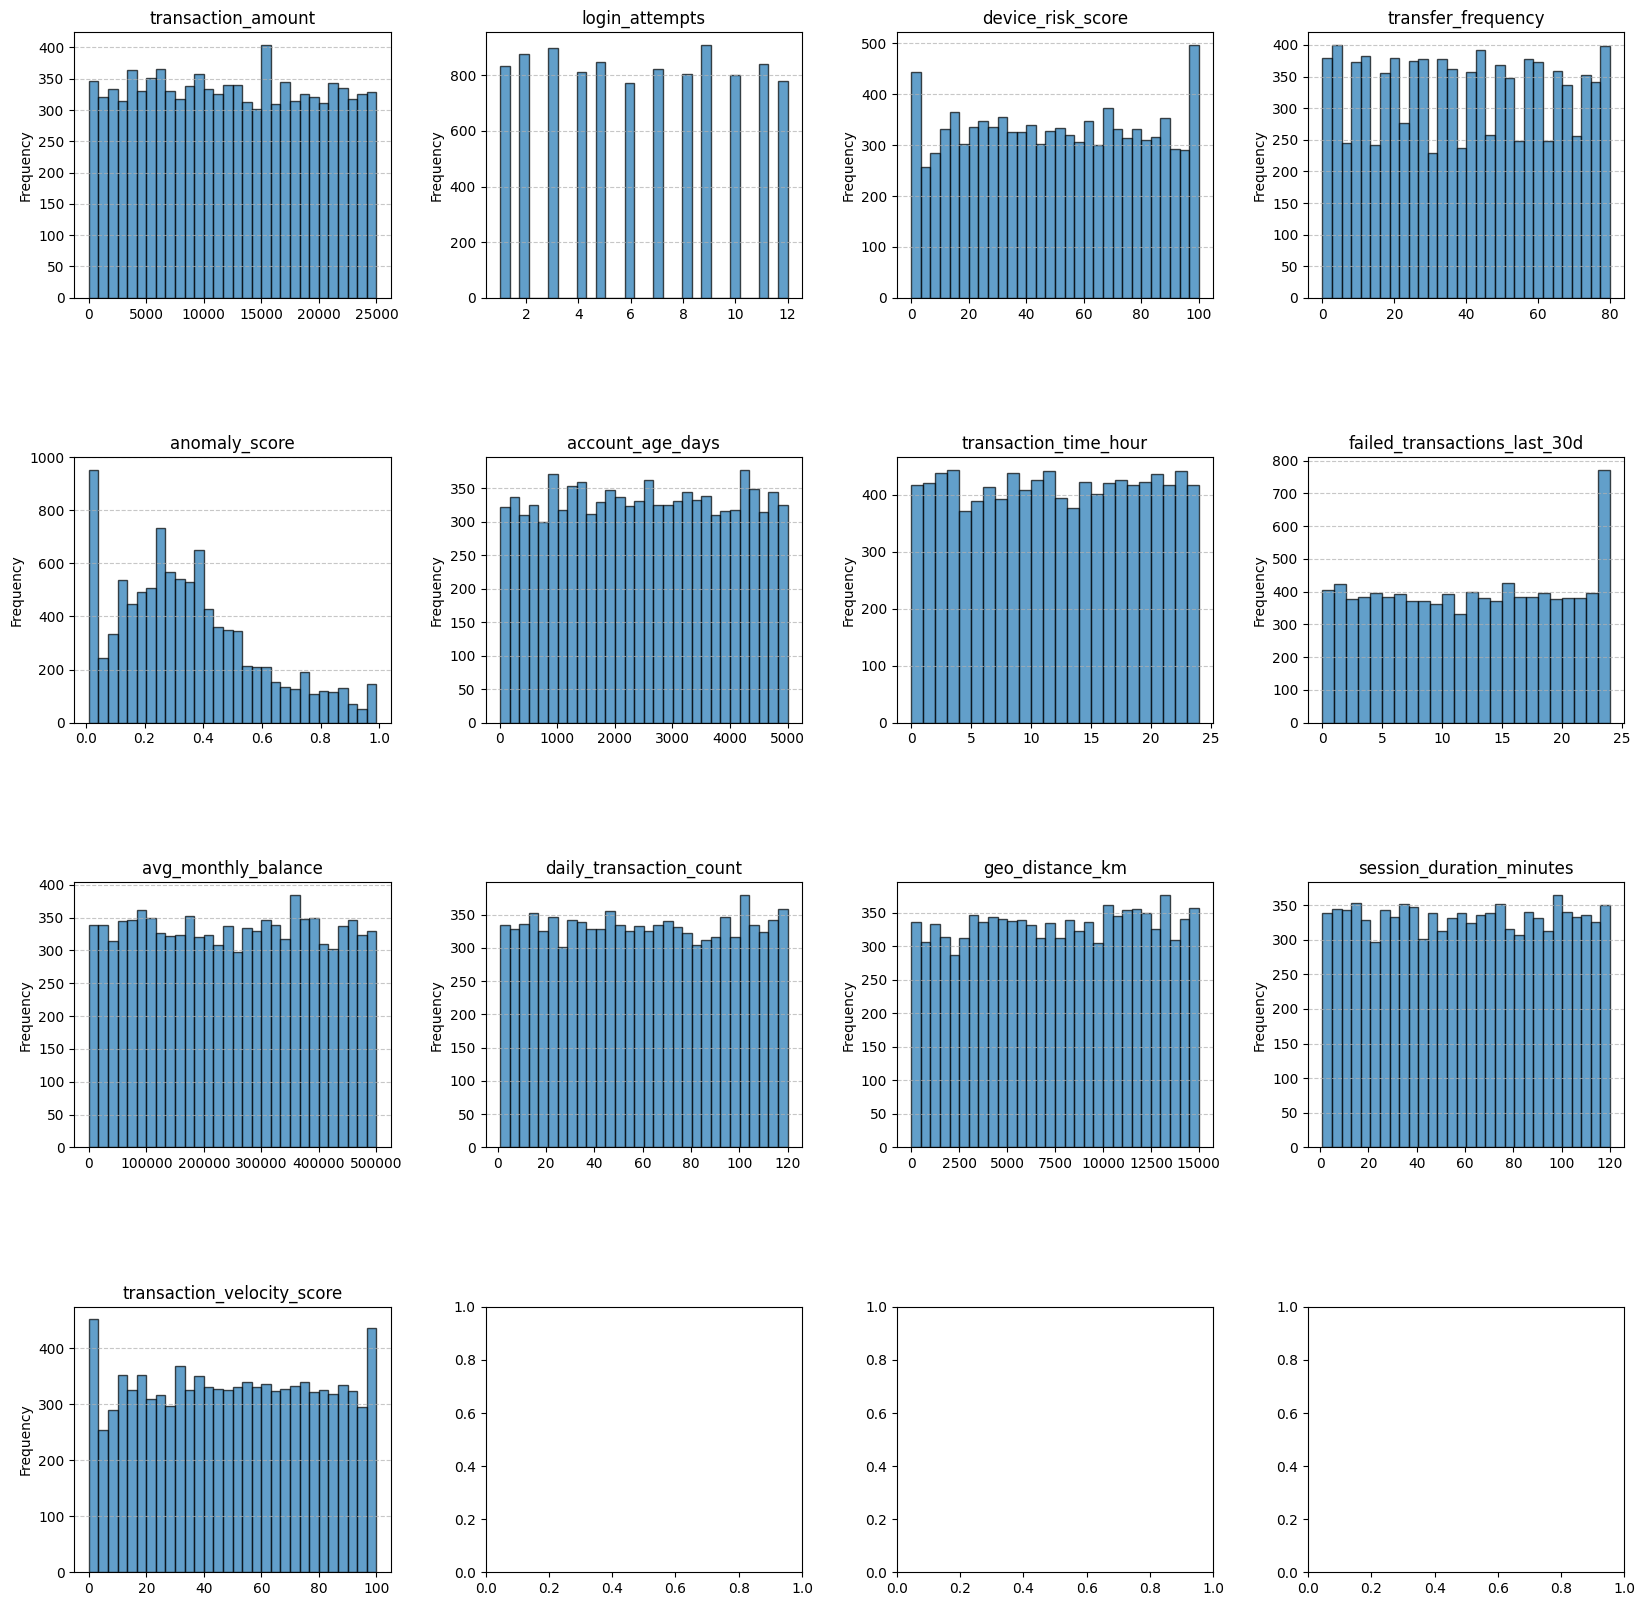


- Categorical Feature Distributions -
payment_channel: {'Mobile App': 4804, 'Web Banking': 3247, 'POS Terminal': 1172, 'ATM': 777}
authentication_type: {'OTP': 4214, 'Two-Factor Authentication': 2384, 'Password Only': 1817, 'Biometric': 1585}


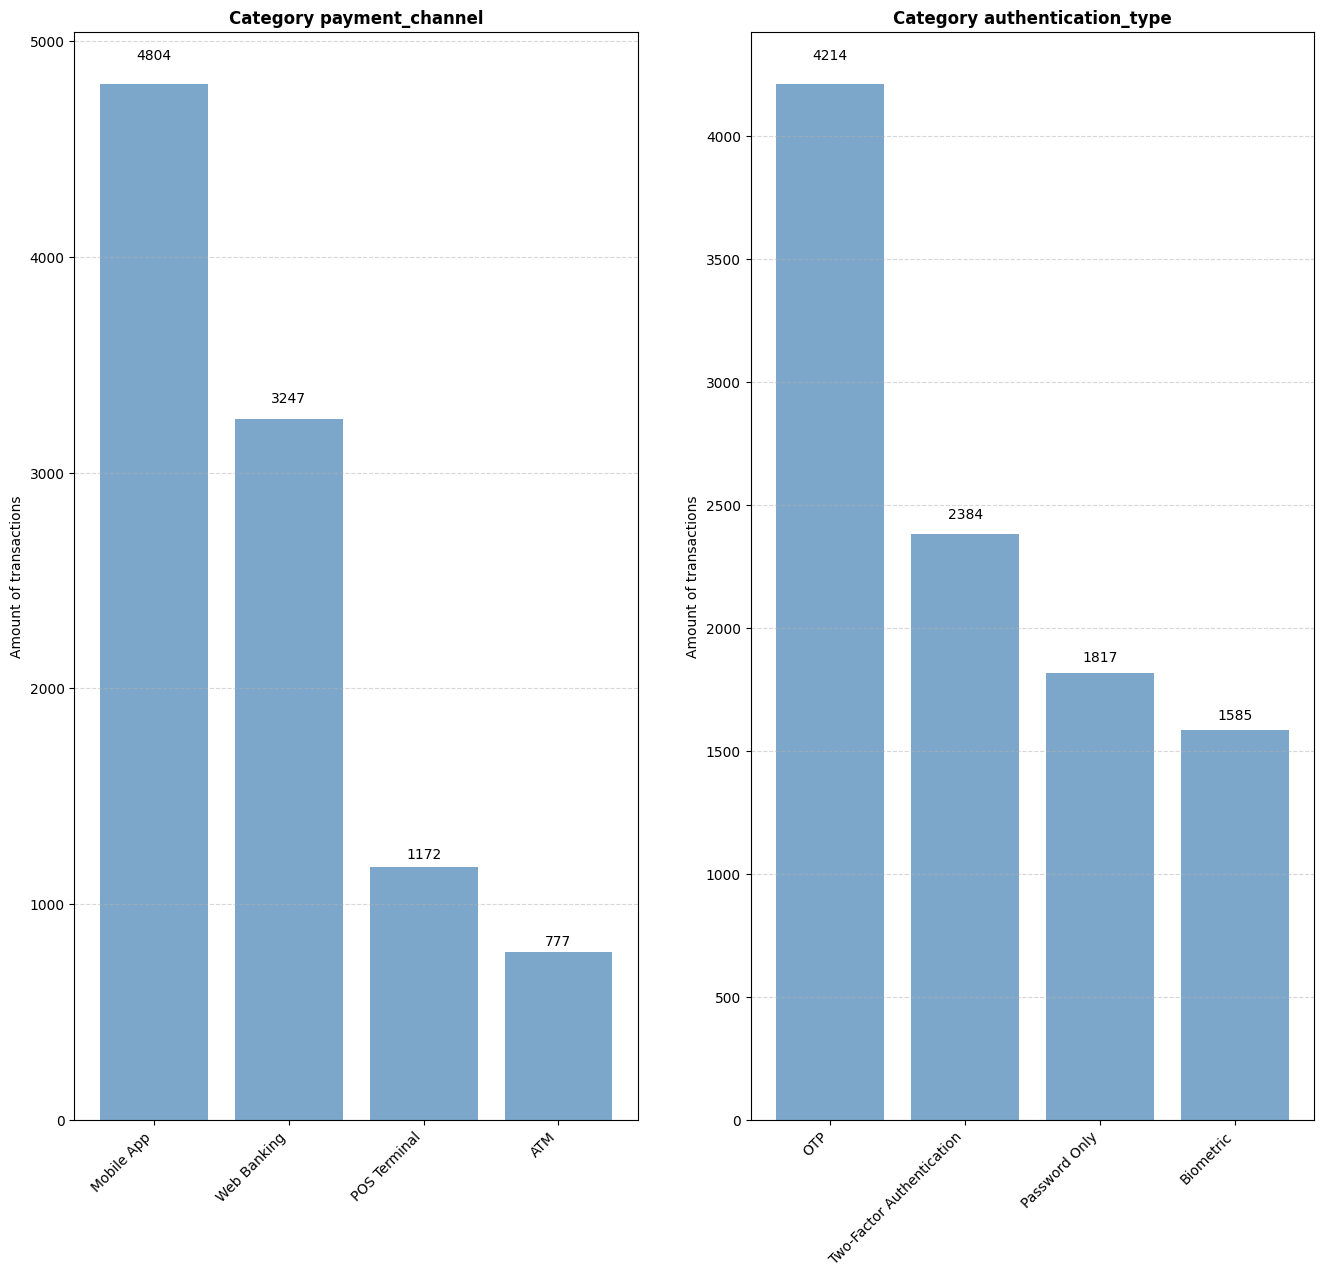


- Binary Feature Distributions -
card_present_flag: {0: 5072, 1: 4928}
international_transaction_flag: {0: 5016, 1: 4984}
suspicious_ip_flag: {1: 5005, 0: 4995}


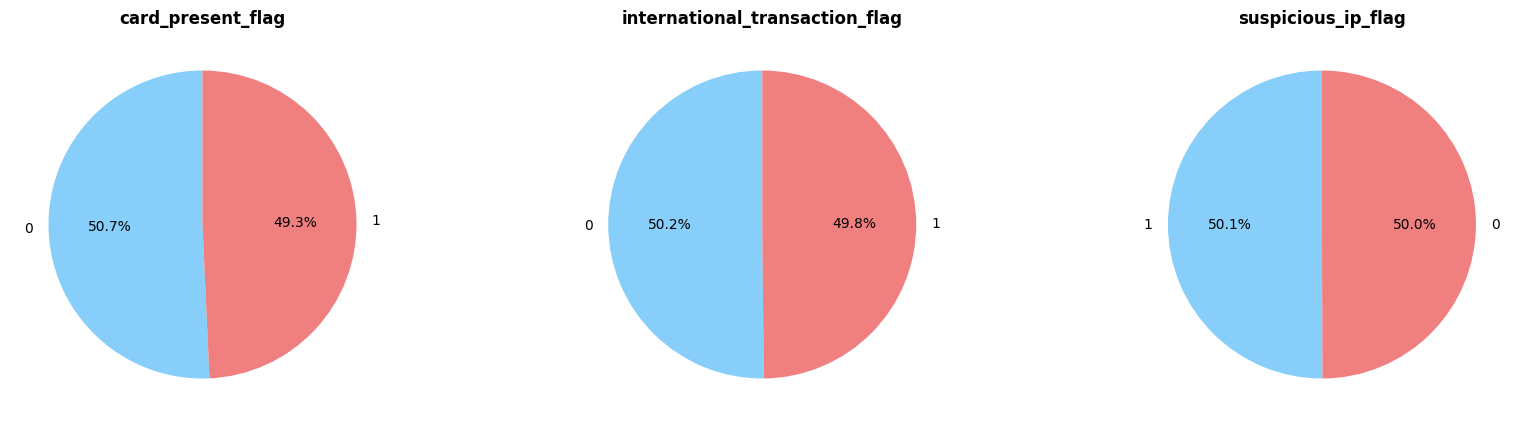


- Target Distribution -
fraud_flag
False    8749
True     1251
Name: count, dtype: int64


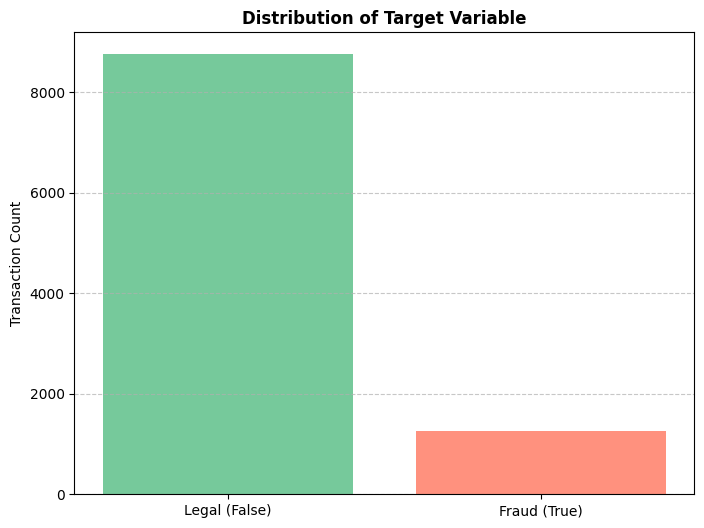

In [ ]:
print("== EXPLORATORY DATA ANALYSIS ==")
print(data.head())

print("\n- Dataset Shape -")
print(data.shape)
print("\n- Dataset Information -")
print(data.info())
print("\n- Missing Values -")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])
print(f"{missing_values.sum()} missing values")
print("\n- Numeric Feature Distributions -")
for col in features["numeric"]:
    print(f"{col}: min={data[col].min()}, max={data[col].max()}, mean={data[col].mean():.2f}, median={data[col].median():.2f}")
visualize_numeric_feature_distributions(data, features["numeric"])
print("\n- Categorical Feature Distributions -")
for col in features["categorical"]:
    print(f"{col}: {data[col].value_counts().to_dict()}")
visualize_categorical_feature_distributions(data, features["categorical"])
print("\n- Binary Feature Distributions -")
for col in features["binary"]:
    print(f"{col}: {data[col].value_counts().to_dict()}")
visualize_binary_feature_distributions(data, features["binary"])
print("\n- Target Distribution -")
class_counts = data['fraud_flag'].value_counts()
print(class_counts)
visualize_target_distribution(data)

### DRZEWO DECYZYJNE


=== Decision Tree Model Performance ===
Accuracy: 0.9185

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1751
           1       0.68      0.65      0.67       249

    accuracy                           0.92      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.92      0.92      0.92      2000



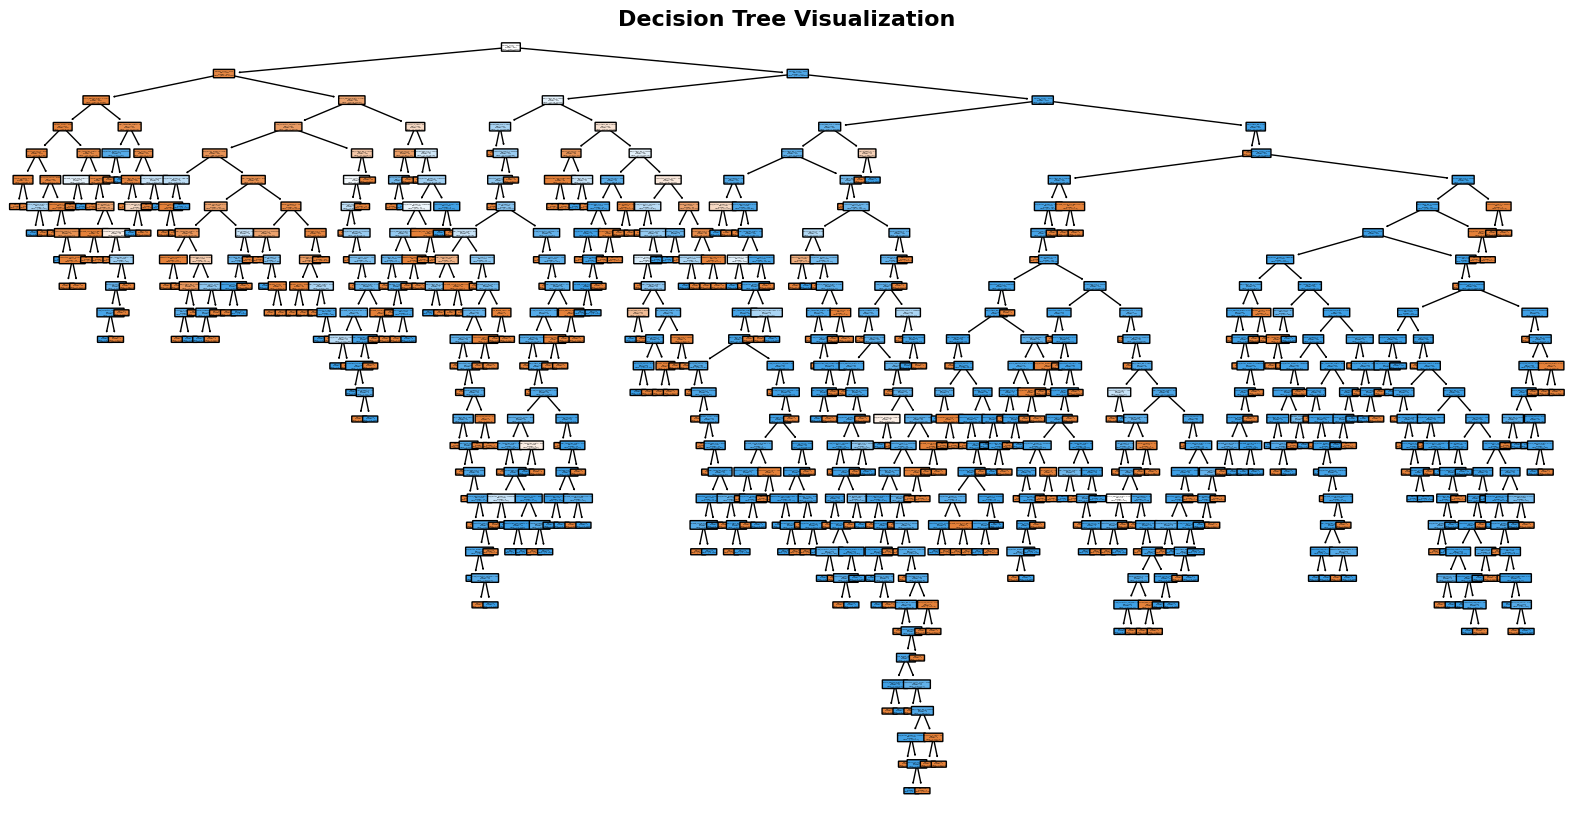

In [ ]:
data = data_encoded

X = data.drop('fraud_flag', axis=1)
y = data['fraud_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = tree.DecisionTreeClassifier(class_weight='balanced', random_state=42) # max_depth żeby zmniejszyć drzewo
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

# Metryki
print("\n=== Decision Tree Model Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Wizualizacja drzewa
plt.figure(figsize=(20, 10))
tree.plot_tree(dt, filled=True, feature_names=X.columns, class_names=['Legal', 'Fraud'], rounded=True)
plt.title("Decision Tree Visualization", fontsize=16, fontweight='bold')
plt.show()

### XGBoost


=== XGBoost Model Performance ===
Accuracy: 0.9415

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1751
           1       0.75      0.80      0.77       249

    accuracy                           0.94      2000
   macro avg       0.86      0.88      0.87      2000
weighted avg       0.94      0.94      0.94      2000



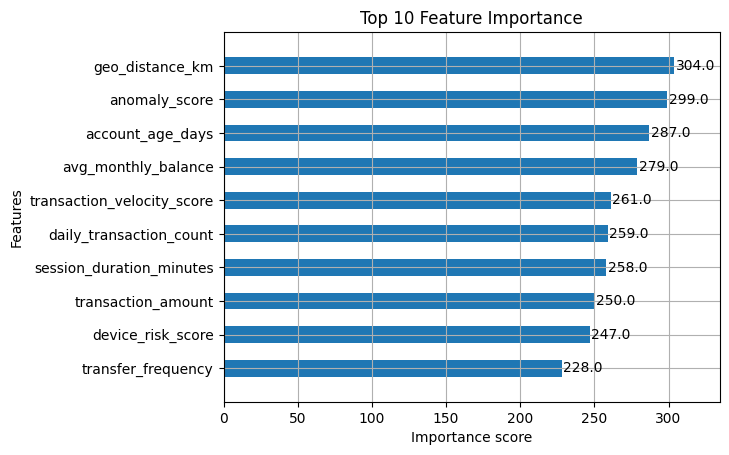

In [9]:
X = data.drop('fraud_flag', axis=1)
y = data['fraud_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

legal_count = sum(y == 0)
fraud_count = sum(y == 1)
weight = legal_count / fraud_count

xgb = XGBClassifier(scale_pos_weight=weight, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

# Metryki
print("\n=== XGBoost Model Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Ważność cech
plot_importance(xgb, max_num_features=10, height=0.5, title='Top 10 Feature Importance')
plt.show()